In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/DailyDelhiClimateTrain.csv")

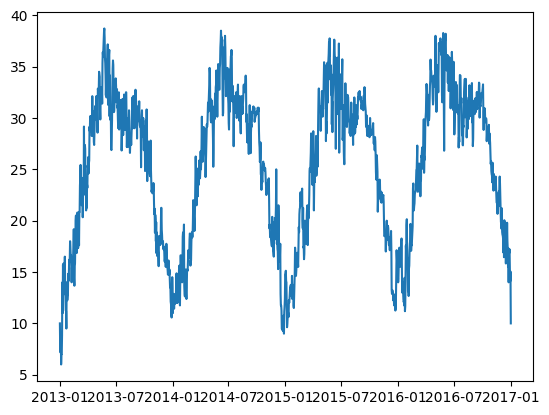

In [3]:


df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

plt.plot(df["meantemp"])
plt.show()

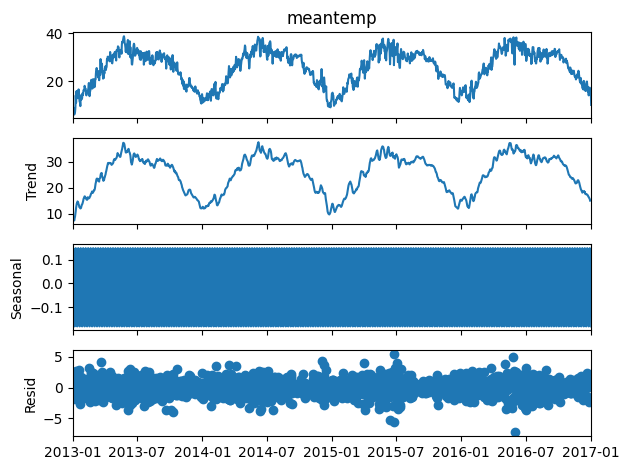

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df["meantemp"],
    model="additive",
    period=7
)

result.plot()
plt.show()

In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["meantemp"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.021069055920673
p-value: 0.2774121372301602


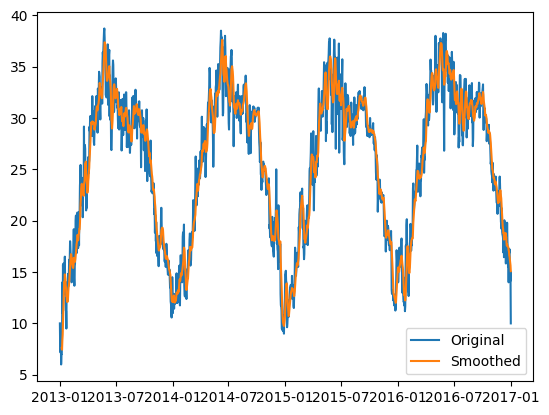

In [6]:
df["MA7"] = df["meantemp"].rolling(7).mean()

plt.plot(df["meantemp"], label="Original")
plt.plot(df["MA7"], label="Smoothed")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2017-01-02    11.354415
2017-01-03    12.130205
2017-01-04    12.574566
2017-01-05    12.829089
2017-01-06    12.974876
2017-01-07    13.058381
2017-01-08    13.106212
Freq: D, Name: predicted_mean, dtype: float64


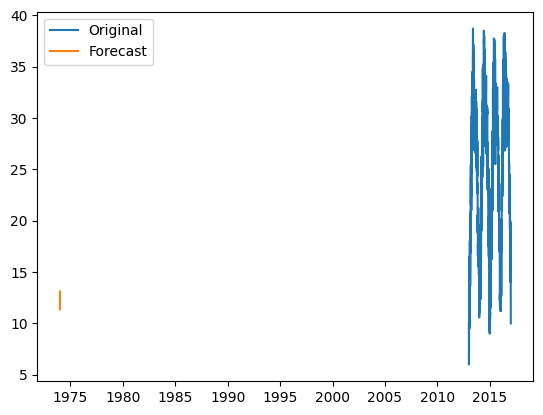

In [7]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["meantemp"], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=7)

print(forecast)

plt.plot(df["meantemp"], label="Original")
plt.plot(range(len(df), len(df)+7), forecast, label="Forecast")

plt.legend()
plt.show()

Accuracy is not suitable for time series forecasting. ARIMA predicts future temperature values based on past observations and trends in the data.